In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from google.colab import files
import pandas as pd

In [29]:
uploaded = files.upload()

print("File 'Study environment VS Productivity.csv' uploaded successfully!")

Saving final.csv to final (3).csv
File 'Study environment VS Productivity.csv' uploaded successfully!


In [30]:
df = df.dropna(how='all')

numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

text_cols = df.select_dtypes(include='object').columns
df[text_cols] = df[text_cols].fillna('Not Specified')

print("Remaining NaN values:", df.isna().sum().sum())
df.head()

Remaining NaN values: 0


,Timestamp,what is your age group?,what is your gender?,Where do you usually study?,On scale from 1-5 how comfortable is your study space?,How many hours do you study per day on average?,how often do you change your study location?,how would you rate your productivity when you change your studying envirnoment?,What are the main source of your distraction?,In which environment are you most productive?,How does noise in your environment affect your ability to focus?,when are you most productive?,Do you feel more productive studying alone or with others?
0,2026/04/05 6:39:10 AM MDT,18-22,Female,Home,4,3-5 hours,Not Specified,2.0,None,with music,4.0,Not Specified,Not Specified
1,2026/04/05 7:25:46 AM MDT,18-22,Female,Home,4,1-2 hours,somtimes,3.0,phone;people;lack of motivation,with music,3.0,Night,Alone
2,2026/04/05 7:27:24 AM MDT,18-22,male,Home,4,3-5 hours,rarely,3.0,phone;lack of motivation,Quiet place,4.0,Morning,Alone
3,2026/04/05 7:31:02 AM MDT,below 18,Female,Home,3,3-5 hours,somtimes,3.0,phone;lack of motivation,with music,3.0,Night,Alone
4,2026/04/05 7:33:39 AM MDT,18-22,male,Home,3,3-5 hours,alway,3.0,people,Quiet place,3.0,Afternoon,Alone


In [31]:
df= pd.read_csv('final.csv')
df.head()

,Timestamp,what is your age group?,what is your gender?,Where do you usually study?,On scale from 1-5 how comfortable is your study space?,How many hours do you study per day on average?,how often do you change your study location?,how would you rate your productivity when you change your studying envirnoment?,What are the main source of your distraction?,In which environment are you most productive?,How does noise in your environment affect your ability to focus?,when are you most productive?,Do you feel more productive studying alone or with others?
0,2026/04/05 6:39:10 AM MDT,18-22,Female,Home,4,3-5 hours,NaN,2.0,NaN,with music,NaN,NaN,NaN
1,2026/04/05 7:25:46 AM MDT,18-22,Female,Home,4,1-2 hours,somtimes,3.0,phone;people;lack of motivation,with music,3.0,Night,Alone
2,2026/04/05 7:27:24 AM MDT,18-22,male,Home,4,3-5 hours,rarely,3.0,phone;lack of motivation,Quiet place,4.0,Morning,Alone
3,2026/04/05 7:31:02 AM MDT,below 18,Female,Home,3,3-5 hours,somtimes,3.0,phone;lack of motivation,with music,3.0,Night,Alone
4,2026/04/05 7:33:39 AM MDT,18-22,male,Home,3,3-5 hours,alway,3.0,people,Quiet place,3.0,Afternoon,Alone


In [38]:

print("Mean values:")
print(df.mean(numeric_only=True))

print("\nMedian values:")
print(df.median(numeric_only=True))

print("\nMode values:")
print(df.mode(numeric_only=True).iloc[0])

Mean values:
On scale from 1-5 how comfortable is your study space?                             3.737500
how would you rate your productivity when you change your studying envirnoment?    3.405063
How does noise in your environment affect your ability to focus?                   3.405063
dtype: float64

Median values:
On scale from 1-5 how comfortable is your study space?                             4.0
how would you rate your productivity when you change your studying envirnoment?    3.0
How does noise in your environment affect your ability to focus?                   4.0
dtype: float64

Mode values:
On scale from 1-5 how comfortable is your study space?                             3.0
how would you rate your productivity when you change your studying envirnoment?    3.0
How does noise in your environment affect your ability to focus?                   4.0
Name: 0, dtype: float64


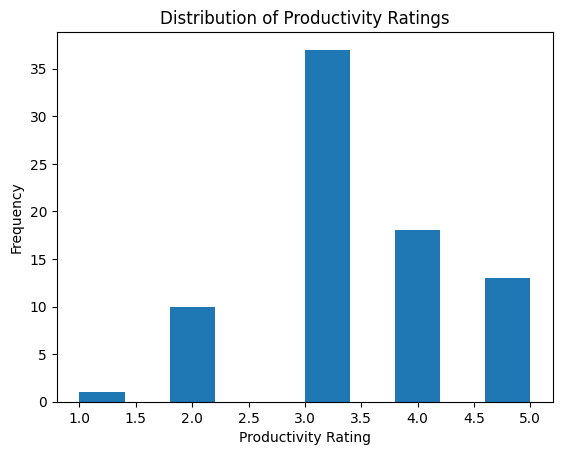

In [33]:
plt.hist(df['how would you rate your productivity when you change your studying envirnoment?'])
plt.xlabel('Productivity Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Productivity Ratings')
plt.show()

In [34]:
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True).str.strip()

dist_col = 'What are the main source of your distraction?'
df[dist_col] = df[dist_col].fillna('None')

split_df = df[dist_col].str.get_dummies(sep=';')

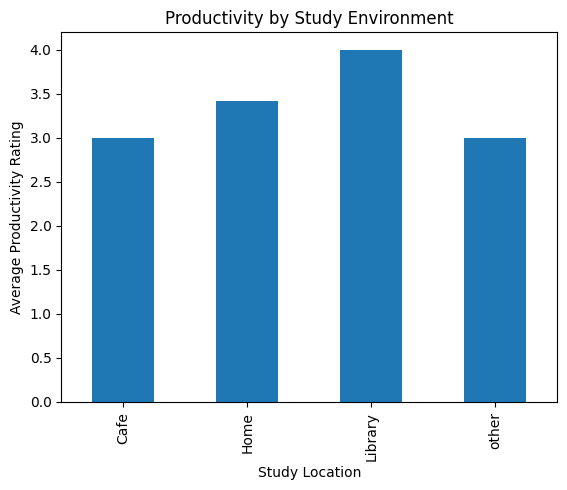

In [35]:

df.groupby('Where do you usually study?')['how would you rate your productivity when you change your studying envirnoment?'].mean().plot(kind='bar')
plt.xlabel('Study Location')
plt.ylabel('Average Productivity Rating')
plt.title('Productivity by Study Environment')
plt.show()

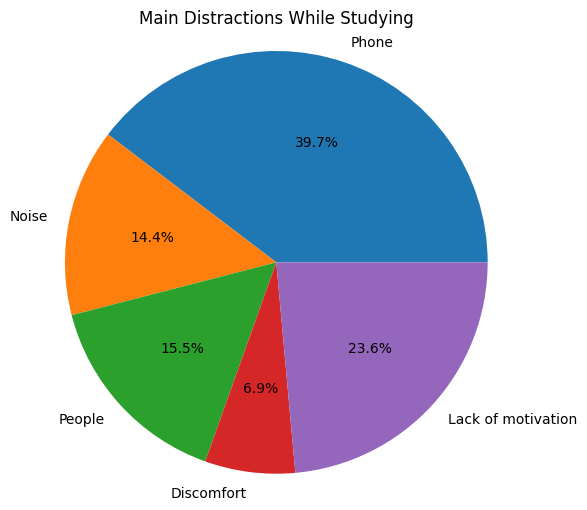

In [36]:
pie_data = pd.Series({
    "Phone": split_df['phone'].sum(),
    "Noise": split_df['noise'].sum(),
    "People": split_df['people'].sum(),
    "Discomfort": split_df['discomfort'].sum(),
    "Lack of motivation": split_df['lack of motivation'].sum()
})

plt.figure(figsize=(6, 6))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%')
plt.title("Main Distractions While Studying")
plt.axis('equal')
plt.savefig('distractions_split_pie.png')

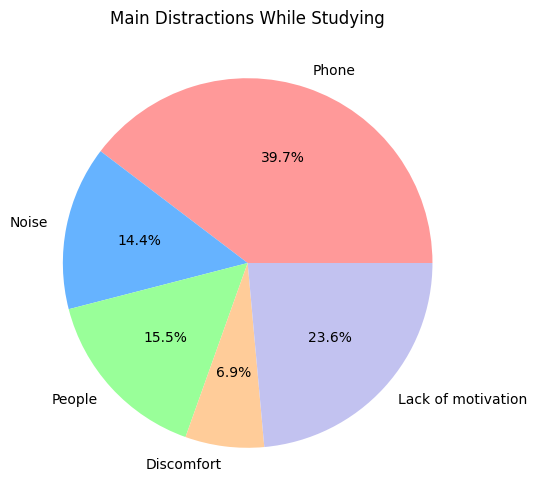

In [37]:
col = 'What are the main source of your distraction?'


counts = pd.Series({
    "Phone": df[col].str.contains('phone', na=False).sum(),
    "Noise":                df[col].str.contains('noise', na=False).sum(),
    "People":               df[col].str.contains('people', na=False).sum(),
    "Discomfort": df[col].str.contains('discomfort', na=False).sum(),
    "Lack of motivation":                df[col].str.contains('lack of motivation', na=False).sum()
})

plt.figure(figsize=(6,6))
counts.plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'])

plt.title("Main Distractions While Studying")
plt.ylabel("") # This removes the 'None' text from the side
plt.show()